# Notebook 1 — Getting Started with Blueprint

Blueprint is a synthetic data library for generating realistic, structured datasets. You define *what* the data should look like — distributions, population segments, causal relationships — and Blueprint handles the generation.

**Use cases:**
- Testing ML pipelines before real data arrives
- Generating training data with known properties
- Populating demos, dashboards, and prototypes
- Stress-testing downstream systems with controlled edge cases

**Design philosophy:**
- Declarative: describe the schema, not the generation loop
- Composable: Features, Classes, and Influences are independent pieces you assemble
- Reproducible: a fixed `seed` always produces the same DataFrame
- No magic: every column value traces back to a parameter you set

## Installation

Clone the repo and install in editable mode:

```bash
git clone https://github.com/your-org/DataSmythe.git
cd DataSmythe
pip install -e .
```

Blueprint depends only on **NumPy** and **pandas**, both of which are installed automatically.

## Imports

The public API lives entirely in the `blueprint` package. The four names you'll use in almost every script:

In [1]:
from blueprint import Blueprint, Feature, Class, Influence

import pandas as pd
import numpy as np

## Minimal working example

The smallest possible Blueprint: one feature, one call to `emit()`.

The three required concepts:
- **`Feature`** — describes one column (name, type, distribution)
- **`Blueprint`** — the orchestrator; owns all features and controls row count
- **`emit()`** — runs the generation pipeline and returns a `pd.DataFrame`

In [2]:
age = Feature("age", dtype=int, base=35, std=10, clip=(18, 80))

bp = Blueprint(n=10, seed=42)
bp.add_feature(age)

df = bp.emit()
df

,age
0,38
1,25
2,43
3,44
4,18
5,22
6,36
7,32
8,35
9,26


Breaking down the `Feature` call:

| Parameter | Meaning |
|-----------|--------|
| `"age"` | Column name in the output DataFrame |
| `dtype=int` | Integer values (drawn from a normal distribution and rounded) |
| `base=35` | Mean of the underlying normal distribution |
| `std=10` | Standard deviation |
| `clip=(18, 80)` | Hard clamp — no value will fall outside this range |

Breaking down the `Blueprint` call:

| Parameter | Meaning |
|-----------|--------|
| `n=10` | Number of rows to generate |
| `seed=42` | RNG seed — same seed always produces the same output |

## A slightly richer example

Adding a few more features to see how multiple columns compose together.

In [3]:
bp = Blueprint(n=200, seed=42)

bp.add_feature(
    Feature("age",    dtype=int,   base=35,    std=10,     clip=(18, 80)),
    Feature("salary", dtype=float, base=65_000, std=20_000, clip=(25_000, None)),
    Feature("active", dtype=bool,  p=0.80),
)

df = bp.emit()
df.head()

,age,salary,active
0,38,71751.490976,True
1,25,93149.637226,True
2,43,66811.698138,True
3,44,77878.775866,False
4,18,25000.000000,True


Notice:
- `clip=(25_000, None)` — `None` means unbounded on that side
- `dtype=bool` with `p=0.80` — 80% of rows will be `True`
- Each feature is generated independently; they don't know about each other at this stage

## Inspecting the output DataFrame

The output is a plain pandas DataFrame — use any pandas tool you already know.

In [4]:
print(df.shape)
print()
print(df.dtypes)
print()
df.describe()

(200, 3)

age         int64
salary    float64
active       bool
dtype: object



,age,salary
count,200.000000,200.000000
mean,34.720000,65544.779601
std,8.747812,20075.808395
min,18.000000,25000.000000
25%,28.000000,51073.741708
50%,34.500000,66208.994012
75%,40.000000,77782.701130
max,64.000000,123101.343385


In [5]:
# Check value distributions
print("Age range:   ", df["age"].min(), "–", df["age"].max())
print("Salary range:", df["salary"].min(), "–", df["salary"].max())
print("Active %:    ", f"{df['active'].mean():.1%}")

Age range:    18 – 64
Salary range: 25000.0 – 123101.34338480813
Active %:     81.0%


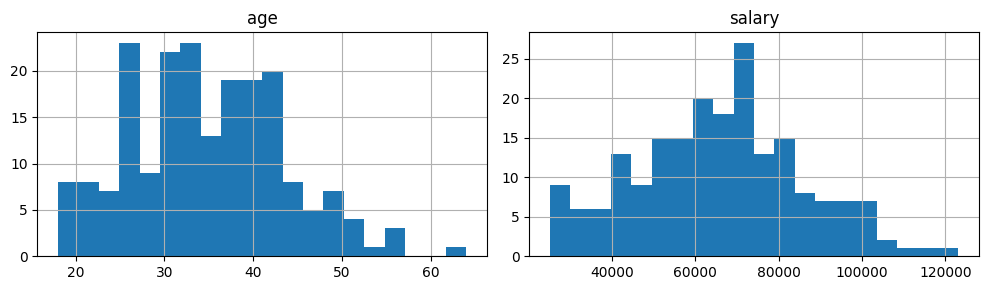

In [6]:
# Quick histogram using pandas
df[["age", "salary"]].hist(bins=20, figsize=(10, 3))
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

## Reproducibility with `seed`

A Blueprint with the same `seed` always emits the exact same DataFrame — regardless of how many times you run it, or in what environment.

In [7]:
def make_bp(seed):
    bp = Blueprint(n=5, seed=seed)
    bp.add_feature(Feature("score", dtype=float, base=100, std=15))
    return bp

# Same seed → identical output
run_1 = make_bp(seed=42).emit()
run_2 = make_bp(seed=42).emit()

print("Run 1:", run_1["score"].values.round(2))
print("Run 2:", run_2["score"].values.round(2))
print("Identical:", run_1["score"].equals(run_2["score"]))

Run 1: [104.57  84.4  111.26 114.11  70.73]
Run 2: [104.57  84.4  111.26 114.11  70.73]
Identical: True


In [8]:
# Different seed → different output
run_3 = make_bp(seed=99).emit()

print("Run 1 (seed=42):", run_1["score"].values.round(2))
print("Run 3 (seed=99):", run_3["score"].values.round(2))
print("Different:", not run_1["score"].equals(run_3["score"]))

Run 1 (seed=42): [104.57  84.4  111.26 114.11  70.73]
Run 3 (seed=99): [101.24  93.03 100.76 110.29  73.65]
Different: True


**Why this matters:**
- Share a seed with a collaborator and you both get the same dataset
- Pin a seed in your tests so assertions never break on re-run
- Change the seed to generate a different-but-structurally-identical dataset (e.g., train vs. test splits)

The seed flows through the entire generation pipeline — base values, class masks, and influence applications all derive from it deterministically.

## Method chaining

`add_feature()`, `add_class()`, and `add_influence()` all return `self`, so you can chain them.

In [9]:
df = (
    Blueprint(n=100, seed=7)
    .add_feature(
        Feature("revenue",   dtype=float, base=50_000, std=15_000, clip=(0, None)),
        Feature("region",    dtype="category", values=["North", "South", "East", "West"]),
        Feature("is_active", dtype=bool, p=0.70),
    )
    .emit()
)

print(df.shape)
df.head()

(100, 3)


,revenue,region,is_active
0,50018.452300,North,False
1,54481.183063,East,True
2,45887.932170,East,False
3,36641.122419,South,True
4,43179.938222,North,False


## What's next

This notebook covered the core loop: `Feature → Blueprint → emit()`. The remaining notebooks go deeper on each building block:

- **Notebook 2** — All Feature dtypes in detail: numeric, boolean, categorical, identity, datetime, text, computed, derived, nullable, and modifiers
- **Notebook 3** — Classes: define population segments and override feature parameters per segment
- **Notebook 4** — Influences: express causal relationships between columns
- **Notebook 5** — The dependency DAG: how Blueprint resolves evaluation order
- **Notebook 6** — Blueprint assembly, validation, description, and output formats